# RF/FM Node Diagnostics


In [1]:
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ast
from tqdm import tqdm
import matplotlib.ticker as ticker

import time
import tracemalloc
import psutil   # pip install psutil  (highly recommended, 1-line install)

def profile_procedure(name: str, func, *args, **kwargs):
    """Wrap ANY function and get time + peak RAM automatically"""
    print(f"\n▶ Starting: {name}")
    tracemalloc.start()
    start_time = time.perf_counter()
    start_ram = psutil.Process().memory_info().rss / 1024**2

    result = func(*args, **kwargs)

    end_time = time.perf_counter()
    end_ram = psutil.Process().memory_info().rss / 1024**2
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    print(f"   ✅ Finished {name}")
    print(f"      Time       : {end_time - start_time:8.3f} seconds")
    print(f"      Peak RAM   : {peak / 1024**2:8.1f} MB (+{end_ram-start_ram:+.1f} MB)")
    print(f"      RSS final  : {end_ram:8.1f} MB\n")
    return result

In [2]:
def load_node_csvs(
    root_pattern: str,
    *,
    exclude_basenames=None,
    read_csv_kwargs=None,
    show_progress: bool = True,
):
    exclude_raw = set(exclude_basenames or [])
    exclude = {
        os.path.splitext(os.path.basename(x))[0]
        for x in exclude_raw
    }
    read_csv_kwargs = dict(read_csv_kwargs or {})

    archivos_all = sorted(glob.glob(root_pattern))
    archivos = [
        p for p in archivos_all
        if os.path.splitext(os.path.basename(p))[0] not in exclude
    ]

    iterator = tqdm(archivos, desc="Loading CSVs") if show_progress else archivos

    datos_nodos = {}
    errors = []
    for archivo in iterator:
        nombre_nodo = os.path.splitext(os.path.basename(archivo))[0]
        try:
            datos_nodos[nombre_nodo] = pd.read_csv(archivo, **read_csv_kwargs)
        except Exception as e:
            errors.append((archivo, str(e)))

    return datos_nodos, archivos, errors


In [3]:

def analyze_psd_nodes(datos_nodos, NODE_NAMES, NODE_LABELS, GLOBAL_RANGE, bin_edges, bin_centers, ALPHA_NODE=0.8):
    """
    Parse PSD values across nodes, build histograms, normalize densities,
    plot global and per-node distributions, and print stats table.

    Parameters
    ----------
    datos_nodos : dict
        Mapping {node_key: DataFrame} with 'pxx' column.
    NODE_NAMES : list
        List of node keys (paths).
    NODE_LABELS : list
        List of node labels (display names).
    GLOBAL_RANGE : tuple
        (min, max) range for PSD values.
    bin_edges : np.ndarray
        Histogram bin edges.
    bin_centers : np.ndarray
        Histogram bin centers.
    ALPHA_NODE : float
        Transparency for per-node plots.
    """
    N_NODES = len(NODE_NAMES)
    N_BINS  = len(bin_edges) - 1

    global_counts = np.zeros(N_BINS, dtype=np.int64)
    node_counts   = {}
    node_stats    = {}

    total_values = 0
    clipped      = 0

    print(f"Parsing pxx across {N_NODES} nodes...")
    for node_key, label in tqdm(zip(NODE_NAMES, NODE_LABELS), total=N_NODES):
        df   = datos_nodos[node_key]
        arrs = []

        for val in df['pxx']:
            if isinstance(val, str):
                arr = np.array(ast.literal_eval(val), dtype=np.float32)
            else:
                arr = np.asarray(val, dtype=np.float32)
            arrs.append(arr)

        flat = np.concatenate(arrs)
        total_values += flat.size
        clipped      += np.sum((flat < GLOBAL_RANGE[0]) | (flat > GLOBAL_RANGE[1]))

        counts, _ = np.histogram(flat, bins=bin_edges)
        node_counts[label]   = counts
        global_counts       += counts
        node_stats[label]    = {'mean': float(np.mean(flat)), 'std': float(np.std(flat))}

    print(f"\n Parsed {total_values:,} values total")
    if clipped:
        pct = 100 * clipped / total_values
        print(f"  {clipped:,} values ({pct:.2f}%) fall outside GLOBAL_RANGE {GLOBAL_RANGE} — adjust if needed")

    # Step 2: Normalise to probability density
    bin_width      = bin_edges[1] - bin_edges[0]
    global_density = global_counts / (global_counts.sum() * bin_width)
    node_densities = {lbl: c / (c.sum() * bin_width) for lbl, c in node_counts.items()}

    # Step 3: Plot
    cmap   = plt.cm.tab10
    colors = [cmap(i / max(N_NODES - 1, 1)) for i in range(N_NODES)]

    fig, axes = plt.subplots(2, 1, figsize=(13, 10),
                              gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.35},
                              layout='constrained')

    # Panel A: Global + per-node overlay
    ax = axes[0]
    ax.fill_between(bin_centers, global_density, alpha=0.15, color='steelblue', label='_nolegend_')
    ax.plot(bin_centers, global_density, color='steelblue', lw=2.2,
            label=f'All nodes  (N={total_values:,})')

    for (lbl, density), color in zip(node_densities.items(), colors):
        mu  = node_stats[lbl]['mean']
        ax.plot(bin_centers, density, lw=1.0, alpha=ALPHA_NODE,
                color=color, label=f"{lbl}  μ={mu:.1f} dB")

    ax.set_xlim(GLOBAL_RANGE)
    ax.set_xlabel('Power Spectral Density (dB)', fontsize=11)
    ax.set_ylabel('Probability Density', fontsize=11)
    ax.set_title('PSD Distribution — All Nodes (per-node overlay)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax.grid(True, which='major', alpha=0.3)
    ax.grid(True, which='minor', alpha=0.1)

    # Panel B: Mean ± 1σ per node
    ax2    = axes[1]
    labels = list(node_stats.keys())
    means  = np.array([node_stats[l]['mean'] for l in labels])
    stds   = np.array([node_stats[l]['std']  for l in labels])
    xs     = np.arange(len(labels))

    ax2.bar(xs, stds, bottom=means - stds, alpha=0.4, color=colors, width=0.6, label='μ ± 1σ')
    ax2.scatter(xs, means, color=colors, zorder=5, s=60, edgecolors='black', lw=0.7)
    ax2.axhline(np.mean(means), color='steelblue', lw=1.5, ls='--', alpha=0.8,
                label=f'Global mean = {np.mean(means):.1f} dB')

    ax2.set_xticks(xs)
    ax2.set_xticklabels(labels, rotation=25, ha='right', fontsize=9)
    ax2.set_ylabel('PSD (dB)', fontsize=10)
    ax2.set_title('Per-Node Mean ± 1σ', fontsize=11, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(5))
    ax2.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Step 4: Print stats table
    print(f"\n{'Node':<20} {'Mean (dB)':>10} {'Std (dB)':>10} {'Rows':>6} {'Values':>12}")
    print('-' * 62)
    for lbl in labels:
        n_rows = len(datos_nodos[next(k for k in NODE_NAMES if k.endswith(lbl))])
        n_vals = node_counts[lbl].sum()
        print(f"{lbl:<20} {node_stats[lbl]['mean']:>10.2f} {node_stats[lbl]['std']:>10.2f} {n_rows:>6} {n_vals:>12,}")
    print('-' * 62)
    print(f"{'GLOBAL':<20} {np.mean(means):>10.2f} {float(np.std(means)):>10.2f} {'':>6} {total_values:>12,}")

    # ── Correlation Matrix of PSD Histogram Shapes ────────────────────────────

    # Stack densities
    density_matrix = np.stack([node_densities[lbl] for lbl in NODE_LABELS])

    # Correlation matrix
    corr_matrix = np.corrcoef(density_matrix)

    # Absolute mean cross-node similarity
    abs_cross_means = (np.abs(corr_matrix).sum(axis=1) - 1.0) / (len(NODE_LABELS) - 1)

    # Ranking
    ranked = sorted(zip(NODE_LABELS, abs_cross_means), key=lambda x: x[1], reverse=True)

    print("\n📊 Ranked by absolute mean cross-node similarity:")
    mean_val, std_val = abs_cross_means.mean(), abs_cross_means.std()
    for rank, (label, cm) in enumerate(ranked, 1):
        flag = "  ⚠️  outlier" if cm < mean_val - std_val else ""
        print(f"  {rank}. {label:<22} | abs mean r = {cm:.4f}{flag}")


    return node_counts, node_stats, global_counts, global_density, node_densities


def rank_psd_histogram_similarity(node_densities, node_labels):
    """
    Compute correlation matrix of PSD histogram shapes and rank nodes
    by absolute mean cross-node similarity.

    Parameters
    ----------
    node_densities : dict
        Mapping {label: density array}.
    node_labels : list
        Ordered list of node labels.

    Returns
    -------
    corr_matrix : np.ndarray
        Correlation matrix (N x N).
    abs_cross_means : np.ndarray
        Absolute mean similarity score per node.
    ranked : list of tuples
        [(label, score)] sorted descending.
    """
    # Stack densities into matrix
    density_matrix = np.stack([node_densities[lbl] for lbl in node_labels])

    # Correlation matrix
    corr_matrix = np.corrcoef(density_matrix)

    # Absolute mean cross-node similarity
    abs_cross_means = (np.abs(corr_matrix).sum(axis=1) - 1.0) / (len(node_labels) - 1)

    # Ranking
    ranked = sorted(zip(node_labels, abs_cross_means), key=lambda x: x[1], reverse=True)

    return corr_matrix, abs_cross_means, ranked

def compute_rankings_over_rows(
    datos_nodos,
    row_range,
    *,
    pxx_scale="dB",
    center_freq_mhz=98.0,
    guard_bins=2,
    noise_q=0.2,
    roi=(97.0, 99.0),
    grid_n=512,
    mi_bins=64,
    normalized=False,
    verbose=False,
):
    """
    True row-wise cumulative-MI ranking:
      for each row:
        1) build aligned / centered spectra per node
        2) compute MI matrix across nodes
        3) compute cumulative MI score per node
        4) rank nodes by descending score
    """
    node_names = sorted(datos_nodos.keys())
    row_range = list(row_range)

    if len(node_names) == 0:
        raise ValueError("datos_nodos is empty.")
    if len(row_range) == 0:
        raise ValueError("row_range is empty.")

    scores_rows = []
    ranks_rows = []

    for r in row_range:
        _, vectors_by_node, _ = build_vectors_for_row(
            datos_nodos,
            r,
            pxx_col="pxx",
            pxx_scale=pxx_scale,
            center_freq_mhz=center_freq_mhz,
            guard_bins=guard_bins,
            noise_q=noise_q,
            roi=roi,
            grid_n=grid_n,
        )

        row_scores = pd.Series(index=node_names, dtype=float, name=r)

        if len(vectors_by_node) >= 2:
            _, scores = cumulative_mi_scores_for_row(
                vectors_by_node,
                mi_bins=mi_bins,
                qrange=(1, 99),
                base=2.0,
                normalized=normalized,
            )
            row_scores.loc[scores.index] = scores

        if verbose:
            n_used = int(row_scores.notna().sum())
            print(f"Row {r}: used {n_used} nodes")

        scores_rows.append(row_scores)

        row_ranks = row_scores.rank(ascending=False, method="dense")
        ranks_rows.append(row_ranks)

    scores_df = pd.DataFrame(scores_rows)
    ranks_df = pd.DataFrame(ranks_rows)

    avg_scores = (
    scores_df.mean(axis=0, skipna=True)
    .sort_values(ascending=False)
    .pipe(lambda s: s  / s.max() )
    .round(4)
    )

    scores_sorted = avg_scores.sort_values(ascending=False)
    # Plot
    plt.figure(figsize=(12, 6))
    plt.semilogy(avg_scores.values, color="blue",marker="o")
    plt.xticks(range(len(scores_sorted.index)), scores_sorted.index, rotation=45, ha="right")

    plt.axhline(y=.9, color='r', linestyle='--', linewidth=2, label='no antenna')
    plt.ylabel("Cumulative MI")
    plt.title("Averaged Node ranking by cumulative MI (descending)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    #print("\nAverage cumulative MI score per node (descending):")
    #print(avg_scores.round(4).to_string())

    return scores_df, ranks_df

def build_vectors_for_row(
    datos_nodos: dict,
    row_idx: int,
    *,
    pxx_col: str = "pxx",
    pxx_scale: str = "dB",
    center_freq_mhz: float = 98.0,
    guard_bins: int = 2,
    noise_q: float = 0.2,
    roi=(97.0, 99.0),
    grid_n: int = 512,
):
    """
    For a given row, return dict {node: vector_on_common_grid}, where each vector is:
      - PSD in dB
      - noise-floor centered (pxx_db - noise_floor)
      - frequency-aligned so detected center bin maps to center_freq_mhz
      - interpolated onto a shared frequency grid in roi
    """
    fmin, fmax = map(float, roi)
    grid = np.linspace(fmin, fmax, int(grid_n))

    vectors = {}

    for nombre_nodo, df in datos_nodos.items():
        if pxx_col not in df.columns:
            continue
        if not (0 <= row_idx < len(df)):
            continue

        try:
            pxx = parse_pxx_cell(df[pxx_col].iloc[row_idx])
        except Exception:
            continue

        if pxx.size == 0:
            continue

        freqs_mhz = get_frequency_axis_mhz(df, row_idx, pxx.size)

        if freqs_mhz.size != pxx.size:
            continue

        # Ensure monotone axis for interpolation
        order = np.argsort(freqs_mhz)
        freqs_mhz = freqs_mhz[order]
        pxx = pxx[order]

        res = detect_center_spike(
            freqs_mhz,
            pxx,
            scale=pxx_scale,
            target_freq=center_freq_mhz,
            guard_bins=guard_bins,
            baseline_mode="quantile",
            baseline_q=noise_q,
            threshold_db=6.0,
        )

        noise_floor_db = res["baseline_db"]

        freqs_aligned_mhz = freqs_mhz + (center_freq_mhz - res["freq"])
        pxx_centered = res["pxx_db"] - noise_floor_db

        y = np.interp(grid, freqs_aligned_mhz, pxx_centered, left=np.nan, right=np.nan)

        if np.isfinite(y).sum() < max(16, grid_n // 10):
            continue

        vectors[nombre_nodo] = y

    return grid, vectors, list(vectors.keys())


### PSD diagnostics for anomaly detection in nodes 


### Looading Loop

In [4]:
# -----------------------
# Config
# -----------------------
ROOT_PATTERN = "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node*.csv"

EXCLUDE_BASENAME  = {
    "DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node8-Bogota", # not enough data
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node5-Bogota", # atipical 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node6-Bogota", # poor quality -- brocken mux 
    #"DataBase-RF-FM-88MHz-108MHz-Bogota-Funza/Node3-Bogota", # poorest measure quality -- without antenna
}

datos_nodos, archivos, errors = load_node_csvs(
    ROOT_PATTERN,
    exclude_basenames=EXCLUDE_BASENAME,
    show_progress=True,
)

Loading CSVs: 100%|██████████| 9/9 [00:05<00:00,  1.79it/s]



#### Histogram Shape Estimation

Parsing pxx across 9 nodes...


100%|██████████| 9/9 [02:04<00:00, 13.81s/it]
/tmp/ipykernel_161587/2221438121.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_161587/2221438121.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



 Parsed 30,932,992 values total
  7,684 values (0.02%) fall outside GLOBAL_RANGE (-27, 6) — adjust if needed


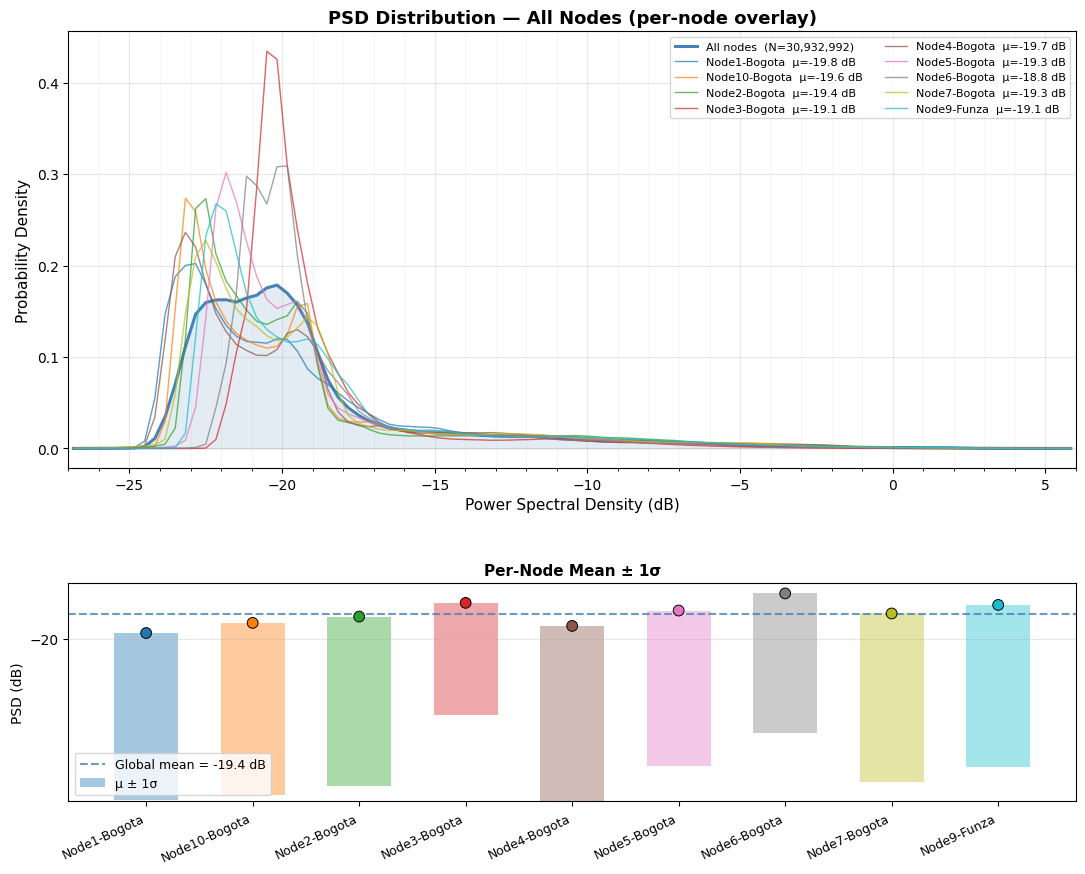


Node                  Mean (dB)   Std (dB)   Rows       Values
--------------------------------------------------------------
Node1-Bogota             -19.85       4.29    105    3,439,202
Node10-Bogota            -19.59       4.42    104    3,407,148
Node2-Bogota             -19.43       4.35    105    3,439,350
Node3-Bogota             -19.08       2.87    105    3,439,687
Node4-Bogota             -19.67       4.50    105    3,440,516
Node5-Bogota             -19.27       3.98    105    3,440,039
Node6-Bogota             -18.83       3.59    105    3,440,031
Node7-Bogota             -19.35       4.32    105    3,438,978
Node9-Funza              -19.13       4.17    105    3,440,357
--------------------------------------------------------------
GLOBAL                   -19.36       0.30          30,932,992

📊 Ranked by absolute mean cross-node similarity:
  1. Node7-Bogota           | abs mean r = 0.8331
  2. Node2-Bogota           | abs mean r = 0.8183
  3. Node9-Funza            | 

In [5]:
# =============================================================================
# 1. CONFIGURATION & PARAMETERS
# =============================================================================

# Node organization (sorted for legend consistency)
NODE_NAMES  = sorted(datos_nodos.keys(), key=lambda x: x.split('/')[-1])
N_NODES     = len(NODE_NAMES)
NODE_LABELS = [n.split('/')[-1] for n in NODE_NAMES]

# PSD histogram binning strategy
pxx_len = 32768  # Expected PSD array length

# Calculate N_BINS using average of Sturges-like and sqrt heuristics
# Note: Using log2(n) + sqrt(n) without +1 term (document your rationale)
N_BINS = int(np.ceil((np.log2(pxx_len) + np.sqrt(pxx_len)) / 2))

# Global value range for consistent histogram comparison across nodes
# Assumption: PSD values are in dB scale; verify this matches your data
GLOBAL_RANGE = (-27, 6)  # (min_dB, max_dB)

# Pre-allocate shared bin edges so every node uses the same grid
bin_edges   = np.linspace(GLOBAL_RANGE[0], GLOBAL_RANGE[1], N_BINS + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])  # For plotting

# =============================================================================
# 2. ANALYSIS 
# =============================================================================

node_counts, node_stats, global_counts, global_density, node_densities = analyze_psd_nodes(
    datos_nodos,
    NODE_NAMES,
    NODE_LABELS,
    GLOBAL_RANGE,
    bin_edges,
    bin_centers,
    ALPHA_NODE=0.72  # Transparency for overlapping histograms
)

| Goal | Minimum Spacing | Preferred Spacing |
|------|----------------|-------------------|
| Basic diversity (omni) | 0.75 m (¼ λ @ 88 MHz) | 1.5–3.0 m (½–1 λ) |
| High isolation / low coupling | 2.8 m | 7.6 m |
| Research-grade spatial independence | 3–6 m (urban) | 10–15 m (open) |
| Your Bogotá–Funza network | Already satisfied (nodes are km apart) | Focus on temporal alignment & calibration |

### cumulative MI ranking 

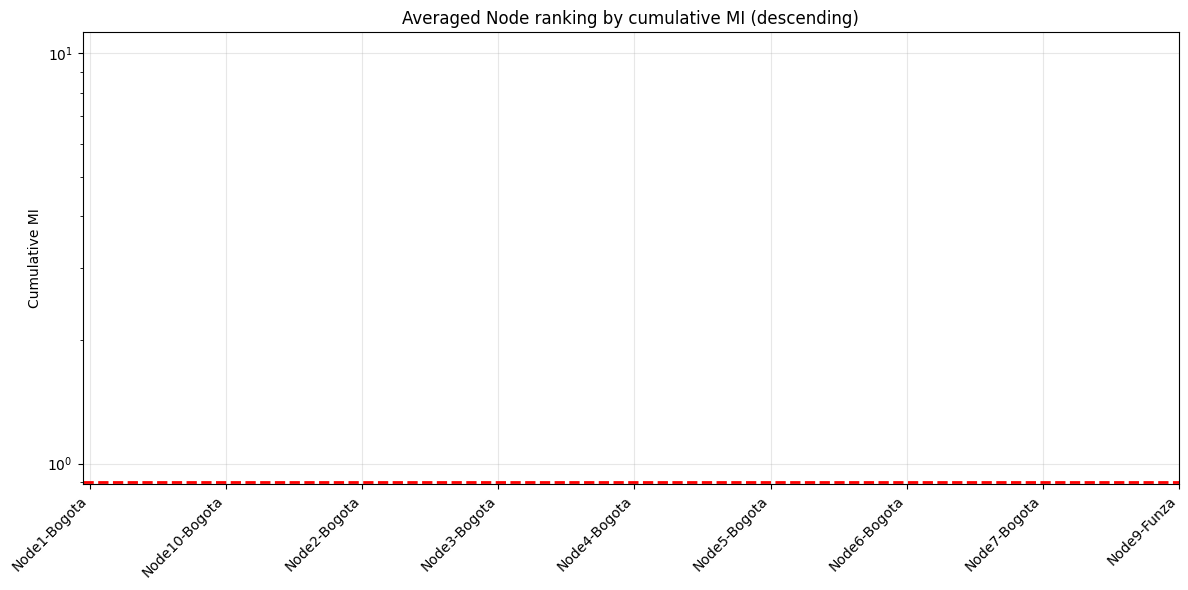

In [6]:
# PSD format
PXX_SCALE       = "dB"       # "dB" if stored in dB, "linear" if stored as linear power
CENTER_FREQ_MHZ = 98.0 # analysis center (band center)
FM_BAND_MHZ    = 20.0          # 108 - 88 MHz
DEFAULT_N_BINS = 1024          # typical FFT size; adjust if different
bin_res_mhz    = FM_BAND_MHZ / (DEFAULT_N_BINS - 1)
fm_half_bw_mhz  = 0.200         # ±200 kHz FM occupied BW
GUARD_BINS      = int(np.ceil(fm_half_bw_mhz / bin_res_mhz)) + 1  
NOISE_Q         = 0.2          # 20th percentile

max_range       = 103
min_range       = 0

# -----------------------
# Averaged cumulative MI ranking over all rows
# -----------------------
scores_df, ranks_df = compute_rankings_over_rows(
    datos_nodos,
    row_range=range(min_range, max_range),
    pxx_scale=PXX_SCALE,
    center_freq_mhz=CENTER_FREQ_MHZ,
    guard_bins=GUARD_BINS,
    noise_q=NOISE_Q,
    roi=(97.0, 99.0),
    grid_n=512,
    mi_bins=64,
    normalized=False,
    verbose=False,
)


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=c4818a93-f2bf-4892-b7a2-47816cd4c47d' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>